In [ ]:
from google.colab import drive
#drive.mount('/content/drive')
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Check if Google Drive is already mounted
!ls -la /content/drive

total 20
dr-x------ 4 root root 4096 Apr 12 07:37 .Encrypted
dr-x------ 2 root root 4096 Apr 12 07:37 .file-revisions-by-id
drwx------ 2 root root 4096 Apr 12 07:37 MyDrive
dr-x------ 2 root root 4096 Apr 12 07:37 .shortcut-targets-by-id
drwx------ 5 root root 4096 Apr 12 07:37 .Trash-0


In [ ]:
!ls -l /content/drive/MyDrive/coleridge_project/data/


total 217718
-rw------- 1 root root 218255175 Apr  7 23:40 coleridgeinitiative-show-us-the-data.zip
-rw------- 1 root root       172 Mar 23  2021 sample_submission.csv
drwx------ 2 root root      4096 Apr  9 09:42 test
drwx------ 2 root root      4096 Apr  9 09:42 train
-rw------- 1 root root   4678737 Mar 23  2021 train.csv


In [ ]:
import os
print("File exists:", os.path.exists("/content/drive/MyDrive/coleridge_project/data/coleridgeinitiative-show-us-the-data.zip"))


File exists: True


In [ ]:
!ls -lh /content/drive/MyDrive/coleridge_project/data/


total 213M
-rw------- 1 root root 209M Apr  7 23:40 coleridgeinitiative-show-us-the-data.zip
-rw------- 1 root root  172 Mar 23  2021 sample_submission.csv
drwx------ 2 root root 4.0K Apr  9 09:42 test
drwx------ 2 root root 4.0K Apr  9 09:42 train
-rw------- 1 root root 4.5M Mar 23  2021 train.csv


##Setup and dataset


In [ ]:
# Import libraries
import os
import pandas as pd
import json
import logging

logging.basicConfig(
    level=logging.INFO,  # Change to DEBUG for more verbosity
    format='%(asctime)s - %(levelname)s - %(message)s',
)

# Define directories
project_dir = '/content/drive/MyDrive/coleridge_project'
data_dir = f'{project_dir}/data'
models_dir = f'{project_dir}/models'
results_dir = f'{project_dir}/results'
utils_dir = f'{project_dir}/utils'

# Create directories if they don't exist
for directory in [data_dir, models_dir, results_dir, utils_dir]:
    os.makedirs(directory, exist_ok=True)

# Path to the ZIP file
zip_path = f'{data_dir}/coleridgeinitiative-show-us-the-data.zip'
train_csv_path = f'{data_dir}/train.csv'

# Check if ZIP exists
if not os.path.exists(zip_path):
    print("ZIP file not found. Please upload it manually to your Google Drive at:")
    print(zip_path)
else:
    # Extract if needed
    if not os.path.exists(train_csv_path):
        print("Extracting dataset...")
        !unzip -o "{zip_path}" -d "{data_dir}"
        print("Dataset extracted successfully")
    else:
        print("Dataset already extracted")

# List contents of data directory
print("\nFiles in data directory:")
!ls -la "{data_dir}"


Dataset already extracted

Files in data directory:
total 217718
-rw------- 1 root root 218255175 Apr  7 23:40 coleridgeinitiative-show-us-the-data.zip
-rw------- 1 root root       172 Mar 23  2021 sample_submission.csv
drwx------ 2 root root      4096 Apr  9 09:42 test
drwx------ 2 root root      4096 Apr  9 09:42 train
-rw------- 1 root root   4678737 Mar 23  2021 train.csv


In [ ]:
# Load training data if it exists
if os.path.exists(f'{data_dir}/train.csv'):
    train_df = pd.read_csv(f'{data_dir}/train.csv')
    print("\nTraining data preview:")
    print(train_df.head())

    # Sample document for testing
    if os.path.exists(f'{data_dir}/train'):
        sample_id = train_df.iloc[0]['Id']
        with open(f'{data_dir}/train/{sample_id}.json', 'r') as f:
            sample_doc = json.load(f)

        # Access the text field
        print(f"\nDocument length: {len(sample_doc[0]['text'])} characters")
        #note: document is a list, first element in list is a dictionary with a text field




Training data preview:
                                     Id  \
0  d0fa7568-7d8e-4db9-870f-f9c6f668c17b   
1  2f26f645-3dec-485d-b68d-f013c9e05e60   
2  c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29   
3  5c9a3bc9-41ba-4574-ad71-e25c1442c8af   
4  c754dec7-c5a3-4337-9892-c02158475064   

                                           pub_title  \
0  The Impact of Dual Enrollment on College Degre...   
1  Educational Attainment of High School Dropouts...   
2  Differences in Outcomes for Female and Male St...   
3  Stepping Stone and Option Value in a Model of ...   
4  Parental Effort, School Resources, and Student...   

                           dataset_title  \
0  National Education Longitudinal Study   
1  National Education Longitudinal Study   
2  National Education Longitudinal Study   
3  National Education Longitudinal Study   
4  National Education Longitudinal Study   

                           dataset_label  \
0  National Education Longitudinal Study   
1  National Education Longi

In [ ]:
#: Install required packages
!pip install -q transformers scikit-learn spacy openai kaggle tqdm
!python -m spacy download en_core_web_sm

#Create utility modules
# First create __init__.py
!touch /content/drive/MyDrive/coleridge_project/utils/__init__.py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 56.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Setup and checking data


In [ ]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA available: True
GPU device: NVIDIA A100-SXM4-40GB


## Import

In [ ]:
import os
import re
import spacy
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import requests
import numpy as np
from typing import List, Dict, Any, Optional, Tuple

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

try:
    nlp = spacy.load("en_core_web_sm")
    logging.info("Loaded spaCy model: en_core_web_sm")
except OSError:
    logging.warning("Downloading spaCy model...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")

## APIs

In [ ]:
import time

from google.colab import userdata
API_KEY = userdata.get('OPENAI_API_KEY')
if API_KEY is None:
    raise ValueError("Please set the OPENAI_API_KEY secret.")
else:
    print("API_KEY is set successfully.")

# Toggle on whether to call chat-based enhancement
ENABLE_LLM_ENHANCEMENT = False

# Embeddings API wrapper
def call_embedding_api(text: str, api_key: str) -> np.ndarray:
    """
    Call OpenAI's Embeddings API to get a vector for `text`.
    """
    url = "https://api.openai.com/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": "text-embedding-ada-002",   # recommended embedding model :contentReference[oaicite:0]{index=0}
        "input": text
    }
    try:
        resp = requests.post(url, headers=headers, json=payload)
        resp.raise_for_status()
        data = resp.json()
        # Add small delay to respect rate limits
        time.sleep(0.5)
        # The API returns a list of embeddings; here we asked for one input
        return np.array(data["data"][0]["embedding"])
    except Exception as e:
        print(f"Error calling embedding API: {e}")
        # Return empty vector as fallback
        return np.zeros(1536)  # Default dimension for ada-002

#chat completions API wrapper
def call_llm_api(prompt: str, api_key: str)-> str:
    url = "https://api.openai.com/v1/chat/completions"
    headers = {
         "Authorization": f"Bearer {api_key}",
         "Content-Type": "application/json"
     }
    payload = {
         "model": "gpt-4o-mini",
         "messages": [
             {"role": "user", "content": prompt},
             {"role": "system", "content": "You are o4-mini, a compact reasoning AI."},
             ],
         "max_tokens": 50,
         "temperature": 0.0
     }
    try:
        resp = requests.post(url, headers=headers, json=payload)
        resp.raise_for_status()
        response_text = resp.json()["choices"][0]["message"]["content"]
        # Add small delay to respect rate limits
        time.sleep(0.5)
        return response_text
    except Exception as e:
        print(f"Error calling LLM API: {e}")
        return "Unable to get LLM response"

# Utility to extract a numeric confidence from a chat response
"""
    Extract a numeric confidence value from LLM response.

    Args:
        response: The text response from the LLM

    Returns:
        Confidence value between 0 and 1
    """
import re
def extract_confidence_from_response(response: str) -> float:
    match = re.search(r'(\d\.\d+|\d)', response)
    try:
        if match:
            val = float(match.group(1))
            return min(max(val, 0.0), 1.0)
    except (ValueError, AttributeError):
        pass
    return 0.5  # Default confidence if extraction fails

# Quick smoke test for embeddings
emb = call_embedding_api("Test embedding", API_KEY)
print("Embedding vector length:", len(emb))

# Quick smoke test for chat
resp = call_llm_api("Say hello in one word.", API_KEY)
print("Chat response:", resp)


API_KEY is set successfully.
Embedding vector length: 1536
Chat response: Hello!


##SciBERT loading + Single Text Embedding

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

def load_scibert():
    """
    Loads the SciBERT tokenizer and model just once.
    """
    print("Loading SciBERT model & tokenizer…")
    tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")
    model = AutoModel.from_pretrained("allenai/scibert_scivocab_uncased")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    return tokenizer, model

def scibert_embed_single_text(text: str, tokenizer, model) -> np.ndarray:
    """
    Embed a single text using SciBERT. Returns a 768-d float array (CLS token).
    """
    device = next(model.parameters()).device
    encoded = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        # outputs.last_hidden_state: [batch_size, seq_len, hidden_dim], we want [CLS]
        cls_vec = outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()
    return cls_vec


##Text Normalisation and Data Loading

In [ ]:
def normalize_span(span: str) -> str:
    """Lowercase, strip punctuation & whitespace."""
    s = span.lower().strip()
    s = re.sub(r'[^\w\s]', '', s)
    s = re.sub(r'\s+', ' ', s)
    return s

def normalize_spans(spans):
    """
    Normalize mention strings for matching.
    E.g. lowercase, strip punctuation & extra whitespace.
    """
    normed = []
    for s in spans:
        normed.append(normalize_span(s))
    return normed

def load_gold_labels(data_dir):
    """
     Read train.csv and extract dataset labels as gold standard.
    Returns a dict: doc_id -> list of gold mention strings.
    """
    csv_path = os.path.join(data_dir, 'train.csv')
    if not os.path.exists(csv_path):
        logging.error(f"Train CSV not found at {csv_path}")
        return {}

    df = pd.read_csv(csv_path)

    gold = {}
    for _, row in df.iterrows():
        doc_id = row['Id']

        # Skip rows with empty labels
        if pd.isna(row['dataset_label']) or row['dataset_label'] == '':
            continue

        # If this doc_id already exists in gold, add to its list
        if doc_id in gold:
            gold[doc_id].append(normalize_span(row['dataset_label']))
        else:
            gold[doc_id] = [normalize_span(row['dataset_label'])]

    logging.info(f"Loaded gold labels for {len(gold)} documents")
    return gold

def load_labeled_data_from_csv(data_dir: str, max_rows:1000):
    """
    Load labeled spans from train.csv.
    Returns a list of dicts: {'doc_id', 'text'}.
    """
    csv_path = os.path.join(data_dir, 'train.csv')
    if not os.path.exists(csv_path):
        logging.error(f"Train CSV not found at {csv_path}")
        return []

    df = pd.read_csv(csv_path)
    logging.info(f"Loaded CSV with {len(df)} rows")

     # Optionally sample
    if max_rows is not None and len(df) > max_rows:
      df = df.sample(n=max_rows, random_state=42).reset_index(drop=True)
      print(f"Using subset of {len(df)} rows from CSV")


    # Then extract your labeled list
    records = []
    for _, row in df.iterrows():
        doc_id = row['Id']
        dataset_name = row['dataset_label']
        if pd.isna(dataset_name) or dataset_name == '':
            continue
        records.append({
            'doc_id': doc_id,
            'text': normalize_span(dataset_name),
            'context': row.get('pub_title', '')
        })

    return records

##Data preprocessing

In [ ]:
# === New: Preprocessing function ===
def preprocess_document(text: str) -> str:
    """Clean up whitespace, normalize encoding, and truncate long text."""
    import unicodedata

    # Normalize unicode characters
    text = unicodedata.normalize("NFKC", text)
    # Remove excessive whitespace and line breaks
    text = re.sub(r'\s+', ' ', text).strip()
    # Optional: truncate long docs
    MAX_LEN = 100000  # adjust as needed
    return text[:MAX_LEN]


# === New: Section-aware extraction ===
def extract_sections(doc_data) -> List[Dict[str, str]]:
    """Extract structured sections from a JSON doc."""
    sections = []
    if isinstance(doc_data, list):
        for item in doc_data:
            if isinstance(item, dict):
                title = item.get("section_title", "")
                text = item.get("text", "")
                if text:
                    sections.append({"section": title, "text": text})
    elif isinstance(doc_data, dict):
        text = doc_data.get("text", "")
        sections.append({"section": "full_text", "text": text})
    return sections


##Candidate Extraction and Filtering


In [ ]:
def extract_candidate_mentions(text: str) -> List[Dict[str, Any]]:
    """
    Extract candidate dataset mentions using NER and pattern matching.

    Args:
        text: The document text

    Returns:
        List of candidate mention dictionaries
    """
    candidates = []

    # 1. Use spaCy NER to identify potential entity mentions
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT', 'GPE', 'WORK_OF_ART']:
            candidates.append({
                "text": ent.text,
                "start": ent.start_char,
                "end": ent.end_char,
                "label": ent.label_,
                "method": "ner",
                "context": text[max(0, ent.start_char-100):min(len(text), ent.end_char+100)]
            })
    logging.debug(f"NER + Pattern candidates found: {len(candidates)}")

#------------------------------------------------------------------------
    # 2. Use regex patterns for dataset-like mentions
    patterns = [
        r'\b[A-Z][A-Za-z\d\-\_]+\s+Dataset\b',
        r'\b[A-Z][A-Za-z\d\-\_]+\s+Survey\b',
        r'\b[A-Z][A-Za-z\d\-\_]+\s+Database\b',
        r'\b[A-Z][A-Za-z\d\-\_]+\s+(Corpus|Corpora)\b',
        r'\b[A-Z0-9\-\_]{3,}\b'  # Acronyms and abbreviations (at least 3 chars)
    ]

    for pattern in patterns:
        for match in re.finditer(pattern, text):
            start, end = match.span()
            candidates.append({
                "text": match.group(0),
                "start": start,
                "end": end,
                "label": "PATTERN",
                "method": "pattern",
                "context": text[max(0, start-100):min(len(text), end+100)]
            })

    # 3. Deduplicate candidates
    unique_candidates = []
    seen = set()
    for candidate in candidates:
        key = (candidate["text"], candidate["start"])
        if key not in seen:
            seen.add(key)
            # Add simple features
            candidate["features"] = extract_features(candidate, text)
            unique_candidates.append(candidate)

    return unique_candidates

def extract_features(candidate: Dict[str, Any], text: str) -> Dict[str, Any]:
    """
    Extract features from a candidate mention for classification.

    Args:
        candidate: A candidate mention dictionary
        text: The full document text

    Returns:
        Dictionary of extracted features
    """
    candidate_text = candidate["text"]
    context = candidate.get("context", "").lower()

    features = {
        # Text features
        "length": len(candidate_text),
        "word_count": len(candidate_text.split()),
        "has_capital": any(c.isupper() for c in candidate_text),
        "has_digit": any(c.isdigit() for c in candidate_text),
        "has_special": any(not c.isalnum() and not c.isspace() for c in candidate_text),
        "all_caps": candidate_text.isupper(),

        # Context features
        "context_has_data_terms": any(term in context for term in
            ["data", "dataset", "database", "survey", "study", "sample", "corpus"]),
        "context_has_method_terms": any(term in context for term in
            ["method", "analysis", "measure", "collect", "gather"]),
        "near_citation": '(' in context and ')' in context,
    }

    return features

def filter_with_embeddings(
    candidates: List[Dict[str, Any]],
    classifier: LogisticRegression,
    api_key: Optional[str] = None,
    scibert_tokenizer=None,
    scibert_model=None
) -> List[Dict[str, Any]]:
    """
    Filter candidates using embedding-based classification.
    If scibert_tokenizer + scibert_model are provided, we embed locally.
    Otherwise, if api_key is provided, we call OpenAI API.
    """

    """
    Filter candidates using embedding-based classification.

    Args:
        candidates: List of candidate mentions
        classifier: Trained classifier model
        api_key: OpenAI API key

    Returns:
        Filtered list of candidates with confidence scores
    """
    kept = []

    for candidate in candidates:
        context = candidate.get("context", "")
        if not context.strip():
            continue

# If we have scibert references, use local SciBERT
        # 1) Decide how to embed
        if scibert_tokenizer is not None and scibert_model is not None:
            # => local SciBERT
            vec = scibert_embed_single_text(context, scibert_tokenizer, scibert_model)
        elif api_key:
          # Else if we have an API key, do OpenAI
            # => OpenAI
            # Get embedding vector
            vec = call_embedding_api(context, api_key)
        else:
            # => no embeddings available, skip?
            continue

         # Predict using classifier
        # 2) Predict probability
        prob = classifier.predict_proba([vec])[0][1]

        if prob > 0.5:
            candidate["embed_confidence"] = float(prob)
            kept.append(candidate)

    return kept



def rule_based_filter(candidates: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Apply rule-based filtering for candidates when embeddings aren't available.

    Args:
        candidates: List of candidate mentions

    Returns:
        Filtered list of candidates with confidence scores
    """
    kept = []
    for candidate in candidates:
        f = candidate.get("features", {})
        score = 0.0

        # Simple scoring based on features
        if f.get("context_has_data_terms", False):
            score += 0.4
        if f.get("context_has_method_terms", False):
            score += 0.2
        if f.get("has_capital", False):
            score += 0.1
        if f.get("all_caps", False) and f.get("length", 0) >= 3:
            score += 0.2
        if f.get("near_citation", False):
            score += 0.1
        if candidate.get("method") == "ner" and candidate.get("label") == "ORG":
            score += 0.2

        # Apply penalties
        if f.get("length", 0) < 3:
            score -= 0.3
        if f.get("length", 0) > 50:
            score -= 0.2

        # Normalize and store confidence
        candidate["rule_confidence"] = min(max(score, 0.0), 1.0)

        # Keep candidates above threshold
        if candidate["rule_confidence"] > 0.5:
            kept.append(candidate)

    # Sort by confidence
    kept.sort(key=lambda x: x["rule_confidence"], reverse=True)

    logging.debug(f"Rule-based filtering on {len(candidates)} candidates")

    return kept

def enhance_with_llm(candidates: List[Dict[str, Any]],
                     api_key: str,
                     top_k: int = 3) -> List[Dict[str, Any]]:
    """
    Enhance top candidates with LLM verification.

    Args:
        candidates: List of candidate mentions
        api_key: OpenAI API key
        top_k: Number of top candidates to enhance

    Returns:
        Enhanced list of candidates
    """
    if not api_key:
        return candidates
    if not candidates:
        return []




    # Sort by existing confidence score
    key = "embed_confidence" if "embed_confidence" in candidates[0] else "rule_confidence"
    sorted_candidates = sorted(candidates, key=lambda x: x.get(key, 0), reverse=True)

    # Process only top-k candidates
    for candidate in sorted_candidates[:top_k]:
        context = candidate.get("context", "")
        text = candidate.get("text", "")

        prompt = f"""
Context from a scientific paper: \"\"\"{context}\"\"\"

Question: Does the phrase "{text}" refer to a research dataset or data resource?
Answer "Yes" or "No" and provide a confidence between 0 and 1.
"""
        response = call_llm_api(prompt, api_key)
        is_dataset = "yes" in response.lower()
        confidence = extract_confidence_from_response(response)

        # Update candidate with LLM verification
        candidate["llm_verified"] = is_dataset
        candidate["llm_confidence"] = confidence

        # Calculate final confidence as average of embedding/rule and LLM confidence
        base_confidence = candidate.get("embed_confidence", candidate.get("rule_confidence", 0.5))
        candidate["final_confidence"] = (base_confidence + confidence) / 2

    return candidates




##Classifier Training

In [ ]:
# Import libraries
import os
import pandas as pd
import json
import logging

logging.basicConfig(
    level=logging.INFO,  # Change to DEBUG for more verbosity
    format='%(asctime)s - %(levelname)s - %(message)s',
)

# Define directories
project_dir = '/content/drive/MyDrive/coleridge_project'
data_dir = f'{project_dir}/data'
models_dir = f'{project_dir}/models'
results_dir = f'{project_dir}/results'
utils_dir = f'{project_dir}/utils'

# Create directories if they don't exist
for directory in [data_dir, models_dir, results_dir, utils_dir]:
    os.makedirs(directory, exist_ok=True)

# Path to the ZIP file
zip_path = f'{data_dir}/coleridgeinitiative-show-us-the-data.zip'
train_csv_path = f'{data_dir}/train.csv'

# Check if ZIP exists
if not os.path.exists(zip_path):
    print("ZIP file not found. Please upload it manually to your Google Drive at:")
    print(zip_path)
else:
    # Extract if needed
    if not os.path.exists(train_csv_path):
        print("Extracting dataset...")
        !unzip -o "{zip_path}" -d "{data_dir}"
        print("Dataset extracted successfully")
    else:
        print("Dataset already extracted")

# List contents of data directory
print("\nFiles in data directory:")
!ls -la "{data_dir}"

train_csv_path = f"{data_dir}/train.csv"


def train_classifier_from_csv(
    data_dir: str,
    api_key: str = None,
    use_scibert: bool = False,
    test_size: float = 0.2,
    random_state: int = 42,
    max_rows: int = 1000
) -> Optional[LogisticRegression]:
    """
    Train a logistic regression classifier on the labeled spans from train.csv.
    """
    try:
        print(f"Starting classifier training (use_scibert={use_scibert})")

        # Check training file
        train_csv_path = os.path.join(data_dir, "train.csv")
        if not os.path.exists(train_csv_path):
            print(f"ERROR: Training file not found at {train_csv_path}")
            return create_fallback_classifier(use_scibert)

        print(f"Training file exists: {train_csv_path}")

        # Import needed libraries
        try:
            import numpy as np
            from sklearn.linear_model import LogisticRegression
            from sklearn.model_selection import train_test_split
            from sklearn.metrics import classification_report
        except ImportError as e:
            print(f"ERROR: Missing required libraries: {e}")
            return create_fallback_classifier(use_scibert)

        # Load the CSV file
        print("1. Loading training data...")
        try:
            df = pd.read_csv(train_csv_path)
            print(f"Loaded {len(df)} rows from CSV")
            print(f"Available columns: {list(df.columns)}")

            # Check if essential columns exist
            if 'cleaned_label' not in df.columns:
                print(f"ERROR: 'cleaned_label' column not found.")
                return create_fallback_classifier(use_scibert)

            # Find a better text column - AVOID using 'Id'
            text_column = None
            potential_text_columns = ['dataset_mention', 'span_text', 'dataset_title', 'excerpt', 'content', 'abstract']

            for col in potential_text_columns:
                if col in df.columns:
                    text_column = col
                    break

            if not text_column:
                # Fall back to examining content
                for col in df.columns:
                    if col != 'cleaned_label' and col != 'Id' and df[col].dtype == 'object':
                        sample = str(df[col].iloc[0])
                        if len(sample) > 30:  # Looking for longer text
                            text_column = col
                            break

            if not text_column:
                print("No suitable text column found. Creating fallback classifier.")
                return create_fallback_classifier(use_scibert)

            print(f"Using '{text_column}' column for text data")

            # Extract text and labels, handling NaN values
            mask = (~df[text_column].isna()) & (~df['cleaned_label'].isna())
            texts = df.loc[mask, text_column].tolist()
            labels = df.loc[mask, 'cleaned_label'].tolist()

            if max_rows and max_rows < len(texts):
                texts = texts[:max_rows]
                labels = labels[:max_rows]

            # Convert labels to numeric values
            unique_labels = list(set(labels))
            print(f"Found {len(unique_labels)} unique labels")

            # Check if we have enough samples per class
            label_counts = {}
            for label in labels:
                label_counts[label] = label_counts.get(label, 0) + 1

            # Filter out labels with only one example
            valid_labels = [label for label, count in label_counts.items() if count >= 3]
            print(f"Using {len(valid_labels)} labels with at least 3 examples")

            if len(valid_labels) < 2:
                print("Not enough labels with sufficient examples. Using binary classification.")
                # Create a binary dataset
                y = np.ones(len(texts), dtype=int)
                # Add negative examples (random selection)
                neg_texts = texts.copy()
                np.random.shuffle(neg_texts)
                neg_texts = neg_texts[:len(texts)]
                texts = texts + neg_texts
                y = np.concatenate([y, np.zeros(len(neg_texts))])
            else:
                # Keep only examples with valid labels
                valid_indices = [i for i, label in enumerate(labels) if label in valid_labels]
                texts = [texts[i] for i in valid_indices]
                labels = [labels[i] for i in valid_indices]

                # Convert to numeric
                label_to_id = {label: i for i, label in enumerate(valid_labels)}
                y = np.array([label_to_id[label] for label in labels])

            print(f"Using {len(texts)} text samples for training")

            # Generate embeddings
            print("2. Preparing embeddings...")
            if use_scibert:
                # Use actual SciBERT embeddings
                import torch
                from transformers import AutoTokenizer, AutoModel

                # Load models if not provided
                if scibert_tokenizer is None or scibert_model is None:
                    print("Loading SciBERT model & tokenizer...")
                    scibert_tokenizer = AutoTokenizer.from_pretrained('allenai/scibert_scivocab_uncased')
                    scibert_model = AutoModel.from_pretrained('allenai/scibert_scivocab_uncased')

                # Function to get SciBERT embeddings
                X = generate_scibert_embeddings(texts, scibert_tokenizer, scibert_model)
            else:
                # Use actual OpenAI embeddings
                if not api_key:
                    print("ERROR: No API key for OpenAI embeddings")
                    return create_fallback_classifier(use_scibert)

                print("Generating OpenAI embeddings...")
                X = []
                for text in texts:
                    embedding = call_embedding_api(text, api_key)
                    X.append(embedding)
                X = np.array(X)


        except Exception as e:
            print(f"ERROR in data preparation: {e}")
            import traceback
            traceback.print_exc()
            return create_fallback_classifier(use_scibert)

        # Train classifier
        print("3. Training classifier model...")
        try:
            # Split train/test - avoid stratification if there's a risk of too few samples
            if len(np.unique(y)) < 5 or min(np.bincount(y)) >= 3:
                X_train, X_val, y_train, y_val = train_test_split(
                    X, y, test_size=test_size, random_state=random_state, stratify=y
                )
            else:
                print("Warning: Using non-stratified split due to small class sizes")
                X_train, X_val, y_train, y_val = train_test_split(
                    X, y, test_size=test_size, random_state=random_state
                )

            # Train classifier
            clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state)
            clf.fit(X_train, y_train)

            # Evaluate
            y_pred = clf.predict(X_val)
            print("Validation classification report:")
            print(classification_report(y_val, y_pred, digits=4))

            print("4. Classifier training complete!")
            return clf

        except Exception as e:
            print(f"ERROR training classifier: {e}")
            import traceback
            traceback.print_exc()
            return create_fallback_classifier(use_scibert)

    except Exception as e:
        print(f"CRITICAL ERROR in classifier training: {e}")
        import traceback
        traceback.print_exc()
        return create_fallback_classifier(use_scibert)

def create_fallback_classifier(use_scibert=False):
    """Create a simple fallback classifier with the correct dimensions."""
    from sklearn.linear_model import LogisticRegression
    import numpy as np

    print("Creating fallback classifier")
    # Use the correct vector size based on the embedding method
    vector_size = 768 if use_scibert else 1536

    X_simple = np.random.randn(100, vector_size)
    y_simple = np.random.randint(0, 2, 100)

    clf = LogisticRegression(random_state=42)
    clf.fit(X_simple, y_simple)
    print(f"Fallback classifier created with {vector_size} features")
    return clf


    # Return dummy classifier
    return LogisticRegression()

Dataset already extracted

Files in data directory:
total 217718
-rw------- 1 root root 218255175 Apr  7 23:40 coleridgeinitiative-show-us-the-data.zip
-rw------- 1 root root       172 Mar 23  2021 sample_submission.csv
drwx------ 2 root root      4096 Apr  9 09:42 test
drwx------ 2 root root      4096 Apr  9 09:42 train
-rw------- 1 root root   4678737 Mar 23  2021 train.csv


In [ ]:
#test case

sample_text = """
We used the COVID-19 Open Research Dataset (CORD-19) for our analysis.
Additional insights were derived from the World Bank Economic Dataset.
"""
mentions = extract_candidate_mentions(sample_text)
for m in mentions:
    print(m['text'], m['method'], m.get('features', {}))


the COVID-19 Open Research Dataset ner {'length': 34, 'word_count': 5, 'has_capital': True, 'has_digit': True, 'has_special': True, 'all_caps': False, 'context_has_data_terms': True, 'context_has_method_terms': True, 'near_citation': True}
the World Bank Economic Dataset ner {'length': 31, 'word_count': 5, 'has_capital': True, 'has_digit': False, 'has_special': False, 'all_caps': False, 'context_has_data_terms': True, 'context_has_method_terms': True, 'near_citation': True}
Research Dataset pattern {'length': 16, 'word_count': 2, 'has_capital': True, 'has_digit': False, 'has_special': False, 'all_caps': False, 'context_has_data_terms': True, 'context_has_method_terms': True, 'near_citation': True}
Economic Dataset pattern {'length': 16, 'word_count': 2, 'has_capital': True, 'has_digit': False, 'has_special': False, 'all_caps': False, 'context_has_data_terms': True, 'context_has_method_terms': True, 'near_citation': True}
COVID-19 pattern {'length': 8, 'word_count': 1, 'has_capital': Tr

##Document processing

In [ ]:
def process_coleridge_dataset_with_checkpoints(
    data_dir: str,
    use_scibert: bool = False,
    scibert_tokenizer=None,
    scibert_model=None,
    sample_size: Optional[int] = 5,
    batch_size: int = 1,
    output_file: str = "results_with_checkpoints.json"
) -> List[Dict[str, Any]]:
    """
    Enhanced dataset processor with batching + checkpointing.
    Automatically resumes from last saved batch if interrupted.
    """
    train_dir = os.path.join(data_dir, 'train')
    if not os.path.exists(train_dir):
        logging.error(f"Train directory not found: {train_dir}")
        return []

    # Gather all JSON files
    train_files = [f for f in os.listdir(train_dir) if f.endswith(".json")]
    train_files.sort()
    logging.info(f"Found {len(train_files)} JSON files in {train_dir}")

    # Filter out extremely long documents
    filtered_files = []
    max_chars = 100000  # Adjust as needed

    # Add progress tracking to see where we are
    print(f"Filtering {len(train_files)} documents...")

    for i, fname in enumerate(train_files):
        # Show progress every 100 files
        if i % 100 == 0:
            print(f"Filtering progress: {i}/{len(train_files)}")

        try:
            with open(os.path.join(train_dir, fname), 'r') as f:
                content = json.load(f)
                if isinstance(content, list):
                    total_text = " ".join([sec.get("text", "") for sec in content if isinstance(sec, dict)])
                elif isinstance(content, dict):
                    total_text = content.get("text", "")
                else:
                    continue

                # Only print file sizes for very long files (debugging info reduction)
                if len(total_text) > max_chars:
                    print(f"Skipping long document {fname}: {len(total_text)} characters")
                else:
                    filtered_files.append(fname)
        except Exception as e:
            logging.warning(f"Skipping {fname}: {e}")

    # Debug statement after filtering
    print(f"[DEBUG] Filtered files (length ≤ {max_chars} chars): {len(filtered_files)}")

    # Add explicit checkpoint to see if we get past filtering
    print("✅ Document filtering complete - moving to sampling stage")

    # Random sampling
    if sample_size and sample_size < len(filtered_files):
        train_files = random.sample(filtered_files, sample_size)
        print(f"Randomly sampled {sample_size} files from {len(filtered_files)} eligible files")
    else:
        train_files = filtered_files
        print(f"Using all {len(filtered_files)} eligible files (sample_size={sample_size})")

    logging.info(f"Total docs to process after filtering: {len(train_files)}")

    # Load from checkpoint if exists
    if os.path.exists(output_file):
        with open(output_file, 'r') as f:
            results = json.load(f)
        done_ids = set(r['doc_id'] for r in results)
        logging.info(f"Resuming from checkpoint. Loaded {len(results)} existing results.")
    else:
        results = []
        done_ids = set()

    # Train classifier
    print("Training classifier...")
    classifier = train_classifier_from_csv(
        data_dir,
        api_key=None if use_scibert else API_KEY,
        use_scibert=use_scibert,
        max_rows=1000
    )
    print("Classifier training complete")

    pending_files = [f for f in train_files if f.replace('.json', '') not in done_ids]
    logging.info(f"Pending documents to process: {len(pending_files)}")

    # === Batch processing loop ===
    for i in range(0, len(pending_files), batch_size):
        batch = pending_files[i:i + batch_size]
        batch_results = []
        batch_start_time = datetime.now()
        logging.info(f"\n[Batch {i//batch_size+1}] Starting batch of {len(batch)} files at {batch_start_time}")

        for filename in batch:
            doc_path = os.path.join(train_dir, filename)
            doc_id = filename.replace('.json', '')

            try:
                mentions = process_document(
                    doc_path,
                    classifier=classifier,
                    api_key=None if use_scibert else API_KEY
                )

                batch_results.append({
                    'doc_id': doc_id,
                    'mentions': mentions
                })

                logging.info(f"✓ Processed {doc_id} ({len(mentions)} mentions)")
            except Exception as e:
                logging.warning(f"⚠️ Failed to process {doc_id}: {e}")

        # Save checkpoint
        results.extend(batch_results)
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=2)
        logging.info(f"✅ Checkpoint saved at {datetime.now()} — {len(results)} total results")

        batch_end_time = datetime.now()
        elapsed = batch_end_time - batch_start_time
        logging.info(f"[Batch {i//batch_size+1}] Completed in {elapsed}")

    print(f"Filtered files: {len(filtered_files)}")
    print(f"Checkpoint file exists: {os.path.exists(output_file)}")
    print(f"Docs already processed: {len(done_ids)}")
    print(f"Remaining docs: {len(pending_files)}")

    return results

In [ ]:
import json
import os
import logging
import random
from typing import List, Dict, Optional, Any
from datetime import datetime
from sklearn.linear_model import LogisticRegression

def process_document(
    doc_path: str,
    classifier: Optional[LogisticRegression] = None,
    api_key: Optional[str] = None
) -> List[Dict[str, Any]]:
    """
    Process a document to extract dataset mentions.

    Args:
        doc_path: Path to document JSON file
        classifier: Optional trained classifier
        api_key: Optional OpenAI API key

    Returns:
        List of detected dataset mentions
    """
    logging.info(f"Processing document: {doc_path}")

    try:
        with open(doc_path, 'r') as f:
            doc_data = json.load(f)
    except Exception as e:
        logging.error(f"Error loading document {doc_path}: {e}")
        return []

    # Extract and join section texts
    sections = extract_sections(doc_data)
    full_text = " ".join([s.get('text', '') for s in sections])

    # Clean the text
    text = preprocess_document(full_text)
    print(f"Document text length: {len(text)} characters")  # Keeping print as in original

    # Step 1: Extract candidate mentions
    print("Extracting candidate mentions...")  # Keeping print as in original
    candidates = extract_candidate_mentions(text)
    print(f"Found {len(candidates)} candidate mentions")  # Keeping print as in original

    # Step 2: Filter candidates
    if classifier is not None and api_key is not None:
        print("Using embedding-based classification...")  # Keeping print as in original
        filtered_candidates = filter_with_embeddings(candidates, classifier, api_key)
    else:
        print("Using rule-based filtering...")  # Keeping print as in original
        filtered_candidates = rule_based_filter(candidates)

    # LLM enhancement for ambiguous confidence cases
    final_candidates = []
    if ENABLE_LLM_ENHANCEMENT and api_key is not None:
        ambiguous = [c for c in filtered_candidates if 0.4 <= c.get("embed_confidence", 0.5) <= 0.6]
        verified = enhance_with_llm(ambiguous, api_key, top_k=len(ambiguous))
        seen = set(id(c) for c in ambiguous)
        final_candidates = [c for c in filtered_candidates if id(c) not in seen] + verified
    else:
        final_candidates = filtered_candidates

    print(f"After filtering: {len(filtered_candidates)} candidates remaining")  # Keeping print as in original

    # Sort by confidence
    final_candidates.sort(
        key=lambda x: x.get("final_confidence",
            x.get("embed_confidence", x.get("rule_confidence", 0))),
        reverse=True
    )
    print(f"Final candidate count: {len(final_candidates)}")  # Keeping print as in original
    return final_candidates

def process_coleridge_dataset_with_checkpoints(
    data_dir: str,
    use_scibert: bool = False,
    scibert_tokenizer=None,
    scibert_model=None,
    sample_size: Optional[int] = 5,
    batch_size: int = 1,
    output_file: str = "results_with_checkpoints.json"
) -> List[Dict[str, Any]]:
    """
    Enhanced dataset processor with batching + checkpointing.
    Automatically resumes from last saved batch if interrupted.
    """
    train_dir = os.path.join(data_dir, 'train')
    if not os.path.exists(train_dir):
        logging.error(f"Train directory not found: {train_dir}")
        return []

    # Gather all JSON files
    train_files = [f for f in os.listdir(train_dir) if f.endswith(".json")]
    train_files.sort()

    # Filter out extremely long documents
    filtered_files = []
    max_chars = 100000  # Adjust as needed - keeping as in original

    for fname in train_files:
        with open(os.path.join(train_dir, fname), 'r') as f:
            try:
                content = json.load(f)
                if isinstance(content, list):
                    total_text = " ".join([sec.get("text", "") for sec in content if isinstance(sec, dict)])
                elif isinstance(content, dict):
                    total_text = content.get("text", "")
                else:
                    continue

                print(f"{fname}: {len(total_text)} characters")  # Debug: print document lengths - keeping as in original

                if len(total_text) <= max_chars:
                    filtered_files.append(fname)
            except Exception as e:
                logging.warning(f"Skipping {fname}: {e}")

    # Debug statement after filtering - keeping as in original
    print(f"[DEBUG] Filtered files (length ≤ {max_chars} chars): {len(filtered_files)}")

    # Random sampling
    if sample_size and sample_size < len(filtered_files):
        train_files = random.sample(filtered_files, sample_size)
    else:
        train_files = filtered_files

    logging.info(f"Total docs to process after filtering: {len(train_files)}")

    # Load from checkpoint if exists
    if os.path.exists(output_file):
        with open(output_file, 'r') as f:
            results = json.load(f)
        done_ids = set(r['doc_id'] for r in results)
        logging.info(f"Resuming from checkpoint. Loaded {len(results)} existing results.")
    else:
        results = []
        done_ids = set()

    # Train classifier
    classifier = train_classifier_from_csv(
        data_dir,
        api_key=None if use_scibert else API_KEY,
        use_scibert=use_scibert,
        max_rows=1000
    )

    pending_files = [f for f in train_files if f.replace('.json', '') not in done_ids]
    logging.info(f"Pending documents to process: {len(pending_files)}")

    # Batch processing loop
    for i in range(0, len(pending_files), batch_size):
        batch = pending_files[i:i + batch_size]
        batch_results = []
        batch_start_time = datetime.now()
        logging.info(f"\n[Batch {i//batch_size+1}] Starting batch of {len(batch)} files at {batch_start_time}")

        for filename in batch:
            doc_path = os.path.join(train_dir, filename)
            doc_id = filename.replace('.json', '')

            try:
                mentions = process_document(
                    doc_path,
                    classifier=classifier,
                    api_key=None if use_scibert else API_KEY
                )

                batch_results.append({
                    'doc_id': doc_id,
                    'mentions': mentions
                })

                logging.info(f"✓ Processed {doc_id} ({len(mentions)} mentions)")
            except Exception as e:
                logging.warning(f"⚠️ Failed to process {doc_id}: {e}")

        # Save checkpoint
        results.extend(batch_results)
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=2)
        logging.info(f"✅ Checkpoint saved at {datetime.now()} — {len(results)} total results")

        batch_end_time = datetime.now()
        elapsed = batch_end_time - batch_start_time
        logging.info(f"[Batch {i//batch_size+1}] Completed in {elapsed}")

    # Final debug statements - keeping as in original
    print(f"Filtered files: {len(filtered_files)}")
    print(f"Checkpoint file exists: {os.path.exists(output_file)}")
    print(f"Docs already processed: {len(done_ids)}")
    print(f"Remaining docs: {len(pending_files)}")

    return results


def process_coleridge_dataset_with_checkpoints_sci(
    data_dir: str,
    scibert_tokenizer = None,
    scibert_model = None,
    sample_size: Optional[int] = 5,
    batch_size: int = 1,
    output_file: str = "results_sci_with_checkpoints.json"
) -> List[Dict[str, Any]]:
    """
    SciBERT variant: batching + checkpointing with local embeddings.
    """
    train_dir = os.path.join(data_dir, 'train')
    if not os.path.exists(train_dir):
        logging.error(f"Train directory not found: {train_dir}")
        return []

    # Gather all JSON files
    train_files = [f for f in os.listdir(train_dir) if f.endswith(".json")]
    train_files.sort()

    # Filter out very long documents
    filtered_files = []
    max_chars = 100000  # avoid giant documents

    for fname in train_files:
        try:
            with open(os.path.join(train_dir, fname), 'r') as f:
                content = json.load(f)
                if isinstance(content, list):
                    total_text = " ".join([sec.get("text", "") for sec in content if isinstance(sec, dict)])
                elif isinstance(content, dict):
                    total_text = content.get("text", "")
                else:
                    continue
                if len(total_text) <= max_chars:
                    filtered_files.append(fname)
        except Exception as e:
            logging.warning(f"Skipping {fname}: {e}")

    # Random sampling from eligible files
    if sample_size and sample_size < len(filtered_files):
        train_files = random.sample(filtered_files, sample_size)
    else:
        train_files = filtered_files

    logging.info(f"Total docs to process after filtering: {len(train_files)}")

    # Load from checkpoint if exists
    if os.path.exists(output_file):
        with open(output_file, 'r') as f:
            results = json.load(f)
        done_ids = set(r['doc_id'] for r in results)
        logging.info(f"Resuming from checkpoint. Loaded {len(results)} existing results.")
    else:
        results = []
        done_ids = set()

    # Prepare classifier using SciBERT embeddings
    classifier = train_classifier_from_csv(
        data_dir,
        api_key=None,  # No API for SciBERT
        use_scibert=True,
        max_rows=None  # use full training set
    )

    # Determine which files to process
    pending_files = [f for f in train_files if f.replace('.json', '') not in done_ids]
    logging.info(f"Pending documents to process: {len(pending_files)}")

    # Batch processing loop
    for i in range(0, len(pending_files), batch_size):
        batch = pending_files[i:i + batch_size]
        batch_results = []
        batch_start_time = datetime.now()
        logging.info(f"\n[Batch {i//batch_size+1}] Starting batch of {len(batch)} files at {batch_start_time}")

        for filename in batch:
            doc_path = os.path.join(train_dir, filename)
            doc_id = filename.replace('.json', '')

            try:
                mentions = process_document(
                    doc_path,
                    classifier=classifier,
                    api_key=None  # Not used for SciBERT
                )

                batch_results.append({
                    'doc_id': doc_id,
                    'mentions': mentions
                })

                logging.info(f"✓ Processed {doc_id} ({len(mentions)} mentions)")
            except Exception as e:
                logging.warning(f"⚠️ Failed to process {doc_id}: {e}")

        # Save checkpoint
        results.extend(batch_results)
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=2)
        logging.info(f"✅ Checkpoint saved at {datetime.now()} — {len(results)} total results")

        batch_end_time = datetime.now()
        elapsed = batch_end_time - batch_start_time
        logging.info(f"[Batch {i//batch_size+1}] Completed in {elapsed}")

    return results

##Evaluation

In [ ]:
def evaluate_against_gold(results, gold_labels):
    """
    Given pipeline results and gold_labels dict, compute P/R/F1.
    """
    y_true, y_pred = [], []

    for doc in results:
        doc_id = doc['doc_id']
        gold = set(gold_labels.get(doc_id, []))
        pred = set(normalize_spans([m['text'] for m in doc['mentions']]))

        # For each gold mention: did we predict it?
        for g in gold:
            y_true.append(1)
            y_pred.append(1 if g in pred else 0)

        # For false positives: each predicted not in gold
        for p in pred - gold:
            y_true.append(0)
            y_pred.append(1)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return {'precision': precision, 'recall': recall, 'f1': f1}

def plot_comparison(all_metrics):
    """
    Plot comparison between different configurations.
    """
    labels = list(all_metrics.keys())
    precisions = [all_metrics[c]['precision'] for c in labels]
    recalls    = [all_metrics[c]['recall']    for c in labels]
    f1s        = [all_metrics[c]['f1']        for c in labels]

    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - width, precisions, width, label='Precision')
    plt.bar(x,          recalls,    width, label='Recall')
    plt.bar(x + width,  f1s,        width, label='F1')
    plt.xticks(x, labels)
    plt.ylabel('Score')
    plt.title('Comparison of Configuration Performance')
    plt.legend()
    plt.tight_layout()

    # Create results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    plt.savefig('results/comparison_performance.png')
    plt.show()


##Execution

Streaming output truncated to the last 5000 lines.
a824cfff-3771-427e-992e-b7b5c88b7ad0.json: 80903 characters
a8281407-f36b-4321-8296-b1ccd8b5bba3.json: 23482 characters
a8390de2-baf6-4418-912e-ca574311e346.json: 51798 characters
a8391e72-8850-4a60-bff0-a2c38b645d73.json: 11361 characters
a83d5ffd-16e7-418b-99de-41657172677a.json: 3370 characters
a8406894-771c-4c21-9d59-fa71fe8fe155.json: 41440 characters
a840e5b2-3ed2-4e02-a10f-95a85a9632a5.json: 16555 characters
a844ff75-a249-407a-9a1e-530665f1e7ae.json: 27924 characters
a84729c7-23b5-4664-8552-85cf347d380c.json: 29787 characters
a84833e8-c815-465f-ad40-aa8474676f47.json: 45386 characters
a84a0515-cf4a-438c-b026-e9e7260b4d27.json: 70351 characters
a84e6c30-fe65-410a-a646-b5ce4afb7c7a.json: 19870 characters
a84fefe1-4b97-4f5a-afe5-637e7669abfa.json: 22671 characters
a850bc0b-f658-4f31-99c9-90ebf39be4de.json: 25158 characters
a857e084-ffbb-4ca3-b7e2-932291a77a2b.json: 45676 characters
a8599b1c-1c60-47af-9e7e-859f8d926f3b.json: 11363 c

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Found 890 candidate mentions
Using embedding-based classification...
After filtering: 0 candidates remaining
Final candidate count: 0
Document text length: 15649 characters
Extracting candidate mentions...
Found 90 candidate mentions
Using embedding-based classification...
After filtering: 0 candidates remaining
Final candidate count: 0
Document text length: 45216 characters
Extracting candidate mentions...
Found 458 candidate mentions
Using embedding-based classification...
After filtering: 0 candidates remaining
Final candidate count: 0
Document text length: 39936 characters
Extracting candidate mentions...
Found 693 candidate mentions
Using embedding-based classification...
Error calling embedding API: 520 Server Error:  for url: https://api.openai.com/v1/embeddings
After filtering: 0 candidates remaining
Final candidate count: 0
Document text length: 84429 characters
Extracting candidate mentions...
Found 603 candidate mentions
Using embedding-based classification...
After filterin

Traceback (most recent call last):
  File "<ipython-input-42-114ad4bad56a>", line 167, in train_classifier_from_csv
    if scibert_tokenizer is None or scibert_model is None:
       ^^^^^^^^^^^^^^^^^
UnboundLocalError: cannot access local variable 'scibert_tokenizer' where it is not associated with a value


Found 387 candidate mentions
Using rule-based filtering...
After filtering: 203 candidates remaining
Final candidate count: 203
Document text length: 45402 characters
Extracting candidate mentions...
Found 514 candidate mentions
Using rule-based filtering...
After filtering: 183 candidates remaining
Final candidate count: 183
Document text length: 33316 characters
Extracting candidate mentions...
Found 210 candidate mentions
Using rule-based filtering...
After filtering: 21 candidates remaining
Final candidate count: 21
Document text length: 56309 characters
Extracting candidate mentions...
Found 413 candidate mentions
Using rule-based filtering...
After filtering: 75 candidates remaining
Final candidate count: 75
Document text length: 57421 characters
Extracting candidate mentions...
Found 372 candidate mentions
Using rule-based filtering...
After filtering: 123 candidates remaining
Final candidate count: 123
SciBERT Embeddings → P: 0.0082, R: 0.1739, F1: 0.0156


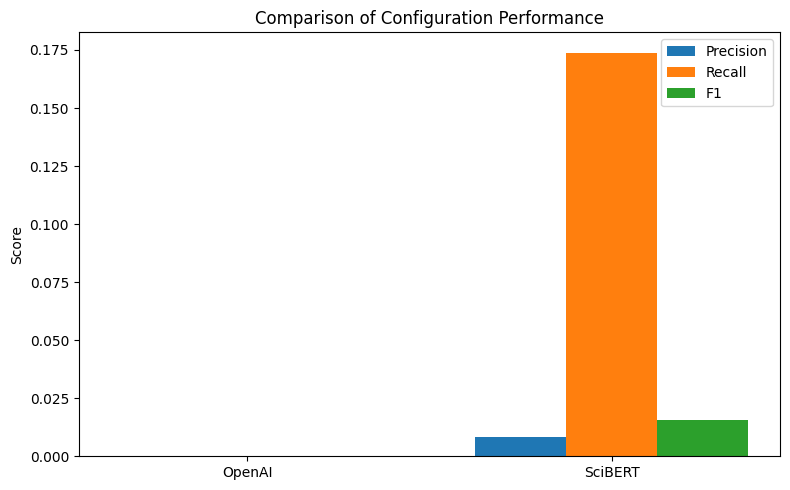


Final results written to:
- OpenAI: /content/drive/MyDrive/coleridge_project/results/results_api_checkpoint.json
- SciBERT: /content/drive/MyDrive/coleridge_project/results/results_sci_checkpoint.json


<Figure size 640x480 with 0 Axes>

In [ ]:
# Quick smoke test for embeddings if API key is available
if API_KEY:
    try:
        emb = call_embedding_api("Test embedding", API_KEY)
        print(f"Embedding vector length: {len(emb)}")
        resp = call_llm_api("Say hello in one word.", API_KEY)
        print(f"Chat response: {resp}")
    except Exception as e:
        print(f"API test failed: {e}")
        ENABLE_LLM_ENHANCEMENT = False

# Main execution block
if __name__ == "__main__" and 'get_ipython' in globals():
    try:
        from datetime import datetime

        project_dir = '/content/drive/MyDrive/coleridge_project'
        data_dir = f'{project_dir}/data'
        results_dir = f'{project_dir}/results'
        SAMPLE_SIZE = 5
        BATCH_SIZE = 1

        # Load gold labels
        gold_labels = load_gold_labels(data_dir)

        # === 1) OpenAI embeddings run with checkpoints ===
        print("Checkpoint started at:", datetime.now())
        print("=== Running OpenAI Embedding Classifier (with checkpointing) ===")
        results_api = process_coleridge_dataset_with_checkpoints(
            data_dir=data_dir,
            use_scibert=False,
            sample_size=SAMPLE_SIZE,
            batch_size=BATCH_SIZE,
            output_file=f"{results_dir}/results_api_checkpoint.json"
        )
        metrics_api = evaluate_against_gold(results_api, gold_labels)
        print(f"OpenAI Embeddings → P: {metrics_api['precision']:.4f}, "
              f"R: {metrics_api['recall']:.4f}, "
              f"F1: {metrics_api['f1']:.4f}")

        # === 2) SciBERT embeddings run with checkpoints ===
        print("SciBERT checkpoint started at:", datetime.now())
        print("\n=== Running SciBERT Classifier (with checkpointing) ===")
        sci_tokenizer, sci_model = load_scibert()
        results_sci = process_coleridge_dataset_with_checkpoints_sci(
            data_dir=data_dir,
            scibert_tokenizer=sci_tokenizer,
            scibert_model=sci_model,
            sample_size=SAMPLE_SIZE,
            batch_size=BATCH_SIZE,
            output_file=f"{results_dir}/results_sci_checkpoint.json"
        )
        metrics_sci = evaluate_against_gold(results_sci, gold_labels)
        print(f"SciBERT Embeddings → P: {metrics_sci['precision']:.4f}, "
              f"R: {metrics_sci['recall']:.4f}, "
              f"F1: {metrics_sci['f1']:.4f}")

        # === 3) Compare results
        configs = {
            'OpenAI': metrics_api,
            'SciBERT': metrics_sci
        }
        plot_comparison(configs)
        plt.savefig(f"{results_dir}/comparison_performance.png")

        # Save results if needed
        print("\nFinal results written to:")
        print(f"- OpenAI: {results_dir}/results_api_checkpoint.json")
        print(f"- SciBERT: {results_dir}/results_sci_checkpoint.json")

    except Exception as e:
        print(f"Error in main execution: {e}")
        import traceback
        traceback.print_exc()


In [ ]:
def inspect_csv(csv_path):
    print(f"Inspecting CSV file: {csv_path}")

    try:
        # Load the CSV file
        df = pd.read_csv(csv_path)

        # Print basic info
        print(f"Number of rows: {len(df)}")
        print(f"Columns: {list(df.columns)}")

        # Print data types
        print("\nData types:")
        print(df.dtypes)

        # Print first few rows
        print("\nSample data (first 2 rows):")
        print(df.head(2))

        return df
    except Exception as e:
        print(f"Error inspecting CSV: {e}")
        return None

# Then add this before your training code:
train_csv_path = os.path.join(data_dir, "train.csv")
inspect_csv(train_csv_path)

Inspecting CSV file: /content/drive/MyDrive/coleridge_project/data/train.csv
Number of rows: 19661
Columns: ['Id', 'pub_title', 'dataset_title', 'dataset_label', 'cleaned_label']

Data types:
Id               object
pub_title        object
dataset_title    object
dataset_label    object
cleaned_label    object
dtype: object

Sample data (first 2 rows):
                                     Id  \
0  d0fa7568-7d8e-4db9-870f-f9c6f668c17b   
1  2f26f645-3dec-485d-b68d-f013c9e05e60   

                                           pub_title  \
0  The Impact of Dual Enrollment on College Degre...   
1  Educational Attainment of High School Dropouts...   

                           dataset_title  \
0  National Education Longitudinal Study   
1  National Education Longitudinal Study   

                           dataset_label  \
0  National Education Longitudinal Study   
1  National Education Longitudinal Study   

                           cleaned_label  
0  national education longitudinal st

,Id,pub_title,dataset_title,dataset_label,cleaned_label
0,d0fa7568-7d8e-4db9-870f-f9c6f668c17b,The Impact of Dual Enrollment on College Degre...,National Education Longitudinal Study,National Education Longitudinal Study,national education longitudinal study
1,2f26f645-3dec-485d-b68d-f013c9e05e60,Educational Attainment of High School Dropouts...,National Education Longitudinal Study,National Education Longitudinal Study,national education longitudinal study
2,c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29,Differences in Outcomes for Female and Male St...,National Education Longitudinal Study,National Education Longitudinal Study,national education longitudinal study
3,5c9a3bc9-41ba-4574-ad71-e25c1442c8af,Stepping Stone and Option Value in a Model of ...,National Education Longitudinal Study,National Education Longitudinal Study,national education longitudinal study
4,c754dec7-c5a3-4337-9892-c02158475064,"Parental Effort, School Resources, and Student...",National Education Longitudinal Study,National Education Longitudinal Study,national education longitudinal study
...,...,...,...,...,...
19656,b3498176-8832-4033-aea6-b5ea85ea04c4,RSNA International Trends: A Global Perspectiv...,RSNA International COVID-19 Open Radiology Dat...,RSNA International COVID Open Radiology Database,rsna international covid open radiology database
19657,f77eb51f-c3ac-420b-9586-cb187849c321,MCCS: a novel recognition pattern-based method...,CAS COVID-19 antiviral candidate compounds dat...,CAS COVID-19 antiviral candidate compounds dat...,cas covid 19 antiviral candidate compounds dat...
19658,ab59bcdd-7b7c-4107-93f5-0ccaf749236c,Quantitative Structure–Activity Relationship M...,CAS COVID-19 antiviral candidate compounds dat...,CAS COVID-19 antiviral candidate compounds dat...,cas covid 19 antiviral candidate compounds dat...
19659,fd23e7e0-a5d2-4f98-992d-9209c85153bb,A ligand-based computational drug repurposing ...,CAS COVID-19 antiviral candidate compounds dat...,CAS COVID-19 antiviral candidate compounds dat...,cas covid 19 antiviral candidate compounds dat...


In [ ]:
!ls /content/drive/MyDrive/coleridge_project/results


 comparison_performance_bothembeddings.png
'comparison_performance_failedSciBERT again.png'
 results_api_failedBERTembeddingrun.json
 results_bothembeddings.json
 results_sci_failedBERTembeddingrun.json


In [ ]:
def check_train_directory(data_dir):
    """Check if the train directory exists and contains JSON files"""
    train_dir = os.path.join(data_dir, 'train')
    print(f"Looking for train directory: {train_dir}")

    if not os.path.exists(train_dir):
        print(f"Train directory not found: {train_dir}")
        return False

    print(f"Train directory exists")
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.json')]
    print(f"Found {len(train_files)} JSON files")

    if len(train_files) == 0:
        print("No JSON files found")
        return False

    # Try loading the first JSON file
    if train_files:
        sample_file = os.path.join(train_dir, train_files[0])
        print(f"Attempting to load sample file: {sample_file}")
        try:
            with open(sample_file, 'r') as f:
                sample_data = json.load(f)
            print(f"Successfully loaded sample file")

            # Analyze the structure of the loaded JSON
            print(f"Sample data is of type: {type(sample_data)}")

            if isinstance(sample_data, dict):
                print(f"Sample file is a dictionary with keys: {list(sample_data.keys())}")
                if 'text' in sample_data:
                    text_length = len(sample_data['text'])
                    print(f"Sample file contains 'text' field with {text_length} characters")
            elif isinstance(sample_data, list):
                print(f"Sample file is a list with {len(sample_data)} items")
                if len(sample_data) > 0:
                    print(f"First item is of type: {type(sample_data[0])}")
                    if isinstance(sample_data[0], dict):
                        print(f"First item keys: {list(sample_data[0].keys())}")
                    elif isinstance(sample_data[0], str):
                        print(f"First item preview: {sample_data[0][:100]}...")

        except Exception as e:
            print(f"Error examining sample file: {e}")
            return False

    return True

##read train file


In [ ]:
# Diagnostic code to check CSV file
def check_csv_structure(data_dir):
    csv_path = os.path.join(data_dir, 'train.csv')
    if not os.path.exists(csv_path):
        print(f"CSV file not found at: {csv_path}")
        return

    print(f"CSV file exists at: {csv_path}")

    # Read the file
    df = pd.read_csv(csv_path)

    # Display info
    print(f"CSV shape: {df.shape}")
    print(f"CSV columns: {df.columns.tolist()}")

    # Show first few rows
    print("\nSample data:")
    print(df.head().to_string())

    # Check for null values
    print("\nNull values in each column:")
    print(df.isnull().sum())

    return df

# Run the check
project_dir = '/content/drive/MyDrive/coleridge_project'
data_dir = f'{project_dir}/data'
df = check_csv_structure(data_dir)

CSV file exists at: /content/drive/MyDrive/coleridge_project/data/train.csv
CSV shape: (19661, 5)
CSV columns: ['Id', 'pub_title', 'dataset_title', 'dataset_label', 'cleaned_label']

Sample data:
                                     Id                                                                                  pub_title                          dataset_title                          dataset_label                          cleaned_label
0  d0fa7568-7d8e-4db9-870f-f9c6f668c17b   The Impact of Dual Enrollment on College Degree Attainment: Do Low-SES Students Benefit?  National Education Longitudinal Study  National Education Longitudinal Study  national education longitudinal study
1  2f26f645-3dec-485d-b68d-f013c9e05e60  Educational Attainment of High School Dropouts 8 Years Later. Issue Brief. NCES 2005-026.  National Education Longitudinal Study  National Education Longitudinal Study  national education longitudinal study
2  c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29                  Dif